# Discrete utility transform 

    JMA 29 Aug 2026

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

DEBUG = 1

In [30]:
# Functions for an exponential utility over x_min, x_max, with r - risk odds

def fit_exp(x_min, x_max, r):
    r_min = pow(r, -x_min)
    r_max = pow(r, -x_max)
    b = 1/(r_min - r_max)
    a = r_min * b
    return a, b

def delta_util_pts(x, xm, xM, r):
    if abs(r -1) < 1e-5:
        b = 1/(xm - xM)
        u = b*(xm - x) 
    else:
        a,b = fit_exp(xm, xM, r)
        if DEBUG: print(f'{a:.3f}, {b:.3f}')
        u =  a - b*np.exp(-x * np.log(r))
    return u

def inverse_delta_util(u, xm, xM, r):
    if abs(r -1) < 1e-5:
        x = xm + u *(xM - xm)
    else:
        a,b = fit_exp(xm, xM, r)
        x = - np.log((a - u)/b)/np.log(r)
    return x


In [31]:
y = delta_util_pts(np.array([-3,-1,0,1,3]), -3,3,1)
print(y)
x1 = inverse_delta_util(y, -3,3,1 )
print(x1)

[-0.          0.33333333  0.5         0.66666667  1.        ]
[-3. -1.  0.  1.  3.]


1.016, 0.127


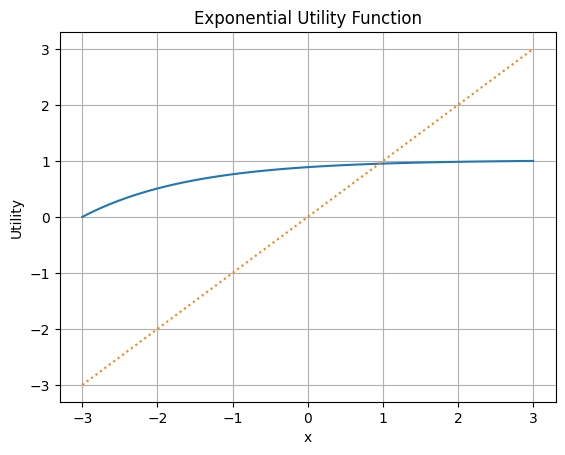

In [36]:
# Test delta utility 
r =   2.0
x_min, x_max = -3,3
x = np.linspace(x_min, x_max, 100)
u = delta_util_pts(x, x_min, x_max, r)
x1 = inverse_delta_util(u, x_min, x_max, r)

plt.plot(x, u)
if DEBUG: plt.plot(x, x1, ':')
plt.xlabel("x")
plt.ylabel("Utility")
plt.title("Exponential Utility Function")
plt.grid(True)
plt.show()

1.096, 0.325
1.096, 0.325


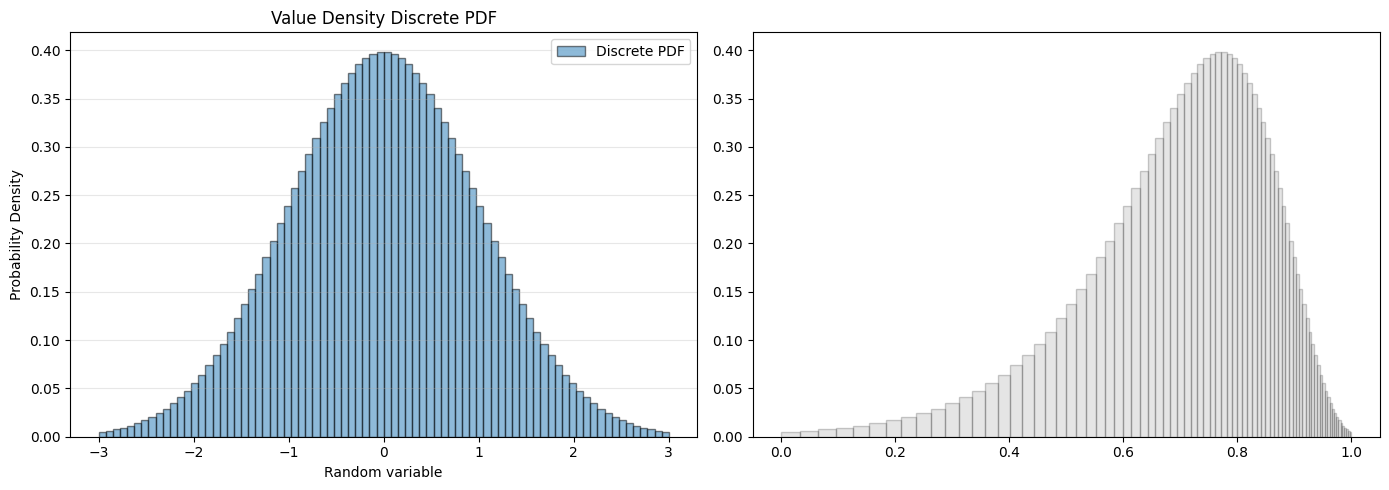

In [38]:
# Transform a discrete normal distribution by an exponential utility

no_bins = 80
r = 1.1
mean = 0
std = 1
# Create bin edges for values (untransformed normal)
v_bin_edges = np.linspace(x_min, x_max, no_bins + 1)
v_bin_width = v_bin_edges[1] - v_bin_edges[0]

# Compute probability in each bin using the CDF
normal_dist = stats.norm(mean, std)
v_bin_probs = np.diff(normal_dist.cdf(v_bin_edges))/v_bin_width
v_bin_centers = (v_bin_edges[:-1] + v_bin_edges[1:]) / 2
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot in value space

ax1.bar(v_bin_centers, v_bin_probs, width=v_bin_width, alpha=0.5,
            edgecolor='black', label='Discrete PDF')
ax1.set_xlabel('Random variable')
ax1.set_ylabel('Probability Density')
ax1.set_title('Value Density Discrete PDF')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Transform - linear into utility space
l_bin_centers = delta_util_pts(v_bin_centers, x_min, x_max, 1.5)
l_bin_edges = delta_util_pts(v_bin_edges, x_min, x_max, 1.5)
l_bin_widths = np.diff(l_bin_edges)

ax2.bar(l_bin_centers, v_bin_probs, width=l_bin_widths, alpha=0.2, color= 'grey',
            edgecolor='black', label='Discrete PDF')
plt.tight_layout()
plt.show()


In [ ]:


def discretize_normal_distribution(mean=0, std=1, no_bins=10, x_range=None):
    """
    Compute a continuous normal distribution and discretize it into bins.
    
    Parameters:
    - mean: Mean of the normal distribution
    - std: Standard deviation of the normal distribution
    - no_bins: Number of bins for discretization
    - x_range: Tuple (min, max) for the range of x values. If None, uses mean +/- 4*std
    
    Returns:
    - bin_edges: Edges of the bins
    - bin_probs: Probability mass in each bin
    - x: x values for plotting the continuous distribution
    - y: Probability density for plotting
    """
    if x_range is None:
        x_range = (mean - 4*std, mean + 4*std)
    
    # Create bin edges
    bin_edges = np.linspace(x_range[0], x_range[1], no_bins + 1)
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Compute probability in each bin using the CDF
    normal_dist = stats.norm(mean, std)
    bin_probs = np.diff(normal_dist.cdf(bin_edges))/bin_width
    
    # Continuous distribution for comparison
    x = np.linspace(x_range[0], x_range[1], no_bins)
    y = normal_dist.pdf(x)
    
    return dict(bin_edges=bin_edges, bin_probs=bin_probs, x=x, y=y, no_bins=no_bins)
# Test 
# discretize_normal_distribution()


In [14]:
from types import SimpleNamespace

def utility_density_plot(**cdfs):
    """
    Plot the probability density of a utility for two distributions
    given as CDFs, comparing their densities on the same axes.

    Parameters are passed as keyword arguments and collected into the
    **cdfs dictionary. The dictionary is parsed to create a local
    variable. 

    The density is computed as the discrete difference of consecutive CDF
    values divided by the bin width, and is plotted as a bar chart for
    each named distribution so the continuous and discretized versions
    can be compared visually.
    """
    # Parse the **two_cdfs dictionary into local variables.
    # After this call, every key in two_cdfs becomes a local variable
    # whose value is the corresponding (bin_edges, cdf) tuple.

    arg = SimpleNamespace(cdfs)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    max_density = 0.0

    bin_edges = np.array(arg.bin_edges)
    bin_widths = np.diff(bin_edges)
    bin_probs = arg.bin_probs
    # density = bin_probs / bin_widths
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    if len(bin_probs) > 0:
        max_density = max(max_density, float(np.max(bin_probs)))

    ax1.bar(bin_centers, bin_probs, width=bin_widths, alpha=0.5,
            edgecolor='black', label='Discrete PDF')

    x = arg.x
    y = arg.y
    # # Overlay a continuous density (if any local variable named 'continuous'
    # # was supplied and exposes a .pdf via scipy.stats) for reference.
    # if 'continuous' in two_cdfs and hasattr(continuous, 'pdf'):
    #     edges = two_cdfs['continuous'][0]
    #     x = np.linspace(edges[0], edges[-1], 1000)
    ax1.plot(x, y, 'k--', linewidth=1.5,
                label='continuous PDF')

    ax1.set_xlabel('Random variable')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Utility Density: Discrete PDF')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    ax2.set_xlabel('Random variable')
    ax2.set_ylabel('Probability Density')
    ax2.set_title('Value Density Discrete PDF')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# utility_density_plot(**discretize_normal_distribution(no_bins=3))
